In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from experiments.comparison import ComparisonConfig, load_datasets
from experiments.plots import learning_curves, equation_curves, forcing_curves, physics_curves, field_slices
from experiments.vorticity_plots import representation_summary, representation_rollouts, vorticity_constraints

torch.set_num_threads(1)
if not torch.cuda.is_available():
    raise RuntimeError("Select the research kernel with CUDA access")
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

In [2]:
datasets = load_datasets(root / "datasets" / "large")
velocity_results = torch.load(
    root / "results" / "phfno_fno_large" / "results.pt",
    map_location="cpu", weights_only=True,
)
config = ComparisonConfig(**velocity_results["config"])
output = root / "results" / "phfno_fno_vorticity"

In [3]:
from importlib import reload
from experiments import vorticity_comparison

reload(vorticity_comparison)
vorticity_results = vorticity_comparison.run_vorticity_comparison(
    datasets, config, output, velocity_reference=velocity_results,
)

PHFNO seed 7:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 7:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 17:   0%|          | 0/3000 [00:00<?, ?step/s]

PHFNO seed 17:   0%|          | 0/3000 [00:00<?, ?step/s]

PHFNO seed 27:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 27:   0%|          | 0/3000 [00:00<?, ?step/s]

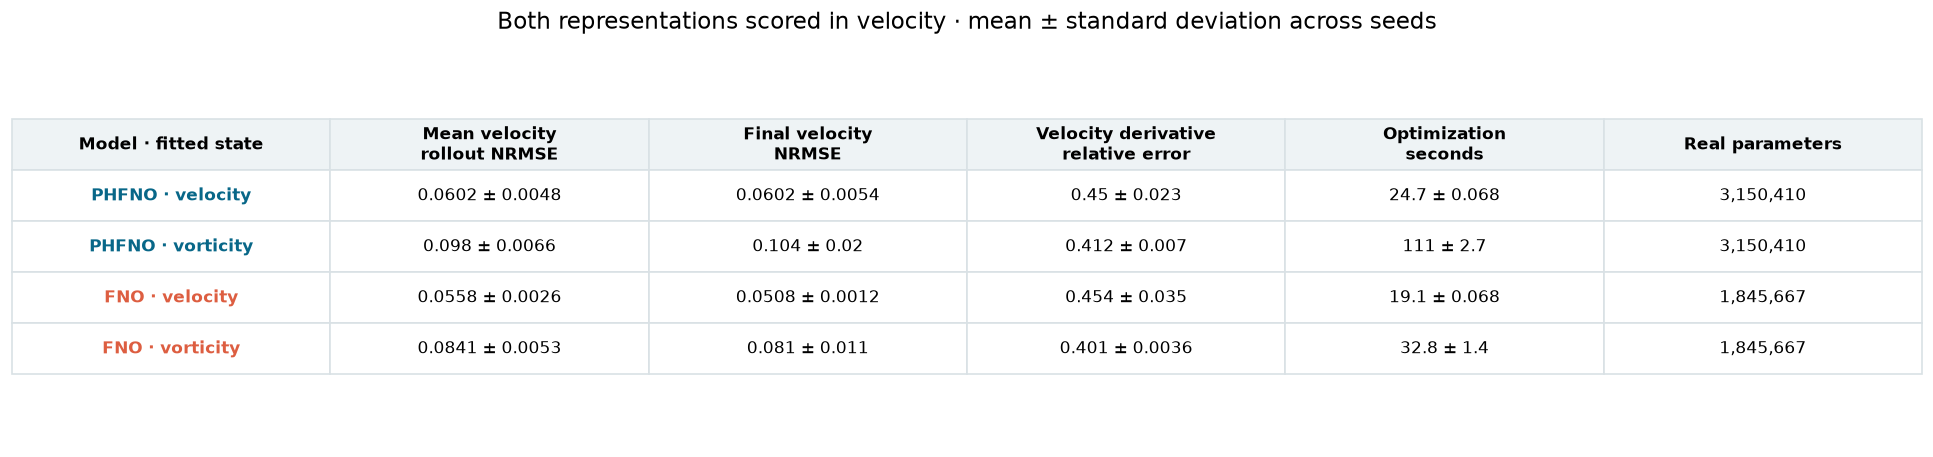

In [4]:
figure = representation_summary(velocity_results, vorticity_results)
plt.show()

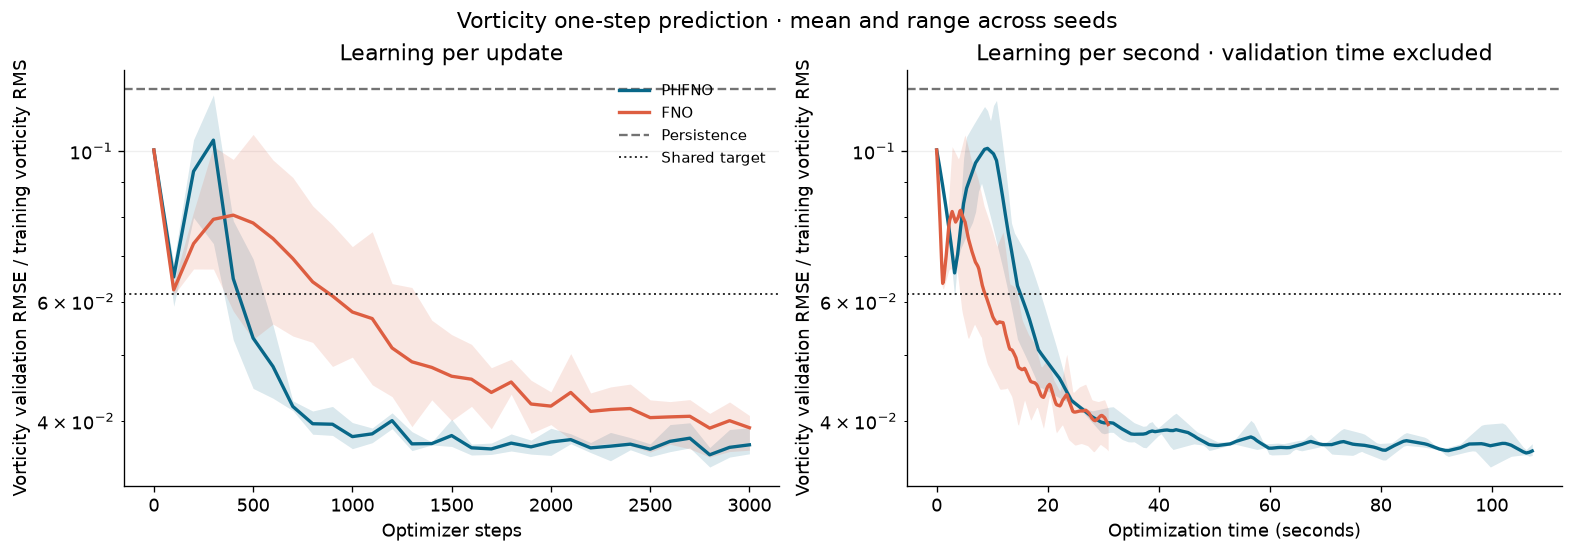

In [6]:
figure = learning_curves(vorticity_results)
figure.suptitle("Vorticity one-step prediction · mean and range across seeds")
for axis in figure.axes:
    axis.set_ylabel("Vorticity validation RMSE / training vorticity RMS")
plt.show()

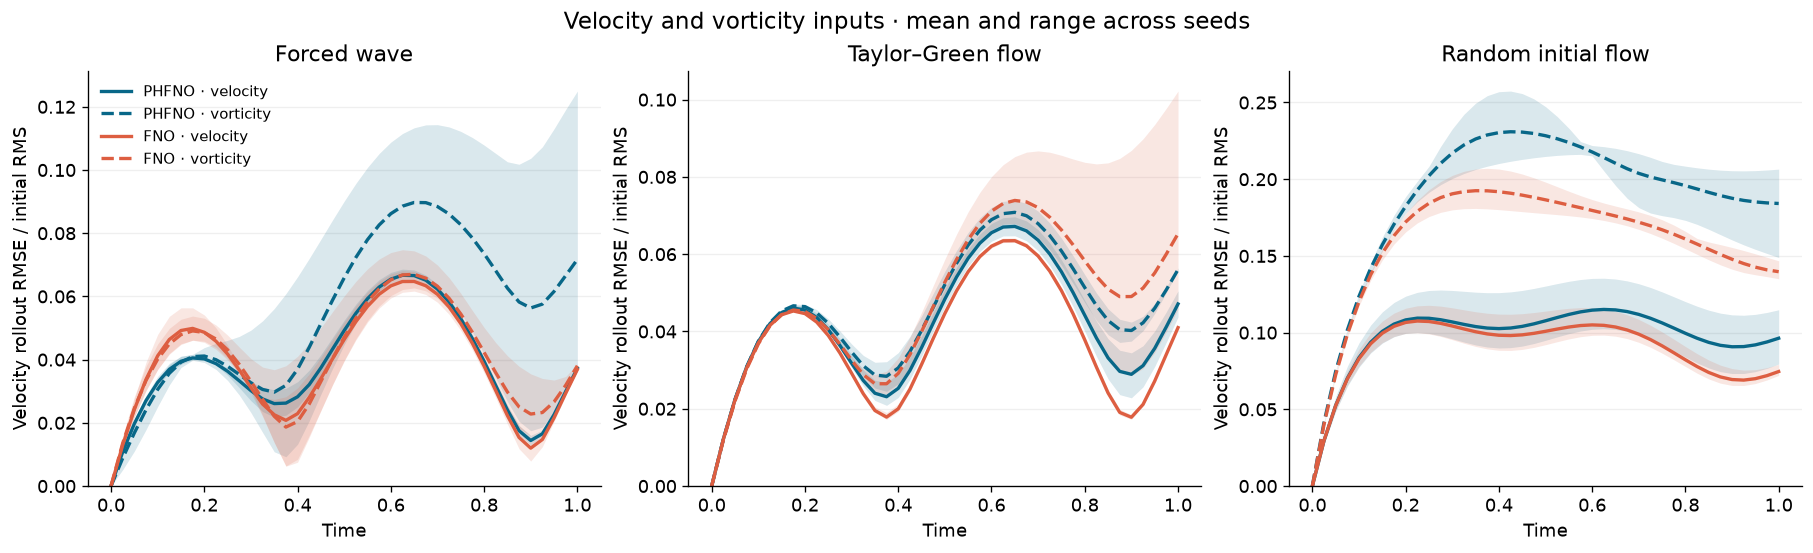

In [7]:
figure = representation_rollouts(velocity_results, vorticity_results)
plt.show()

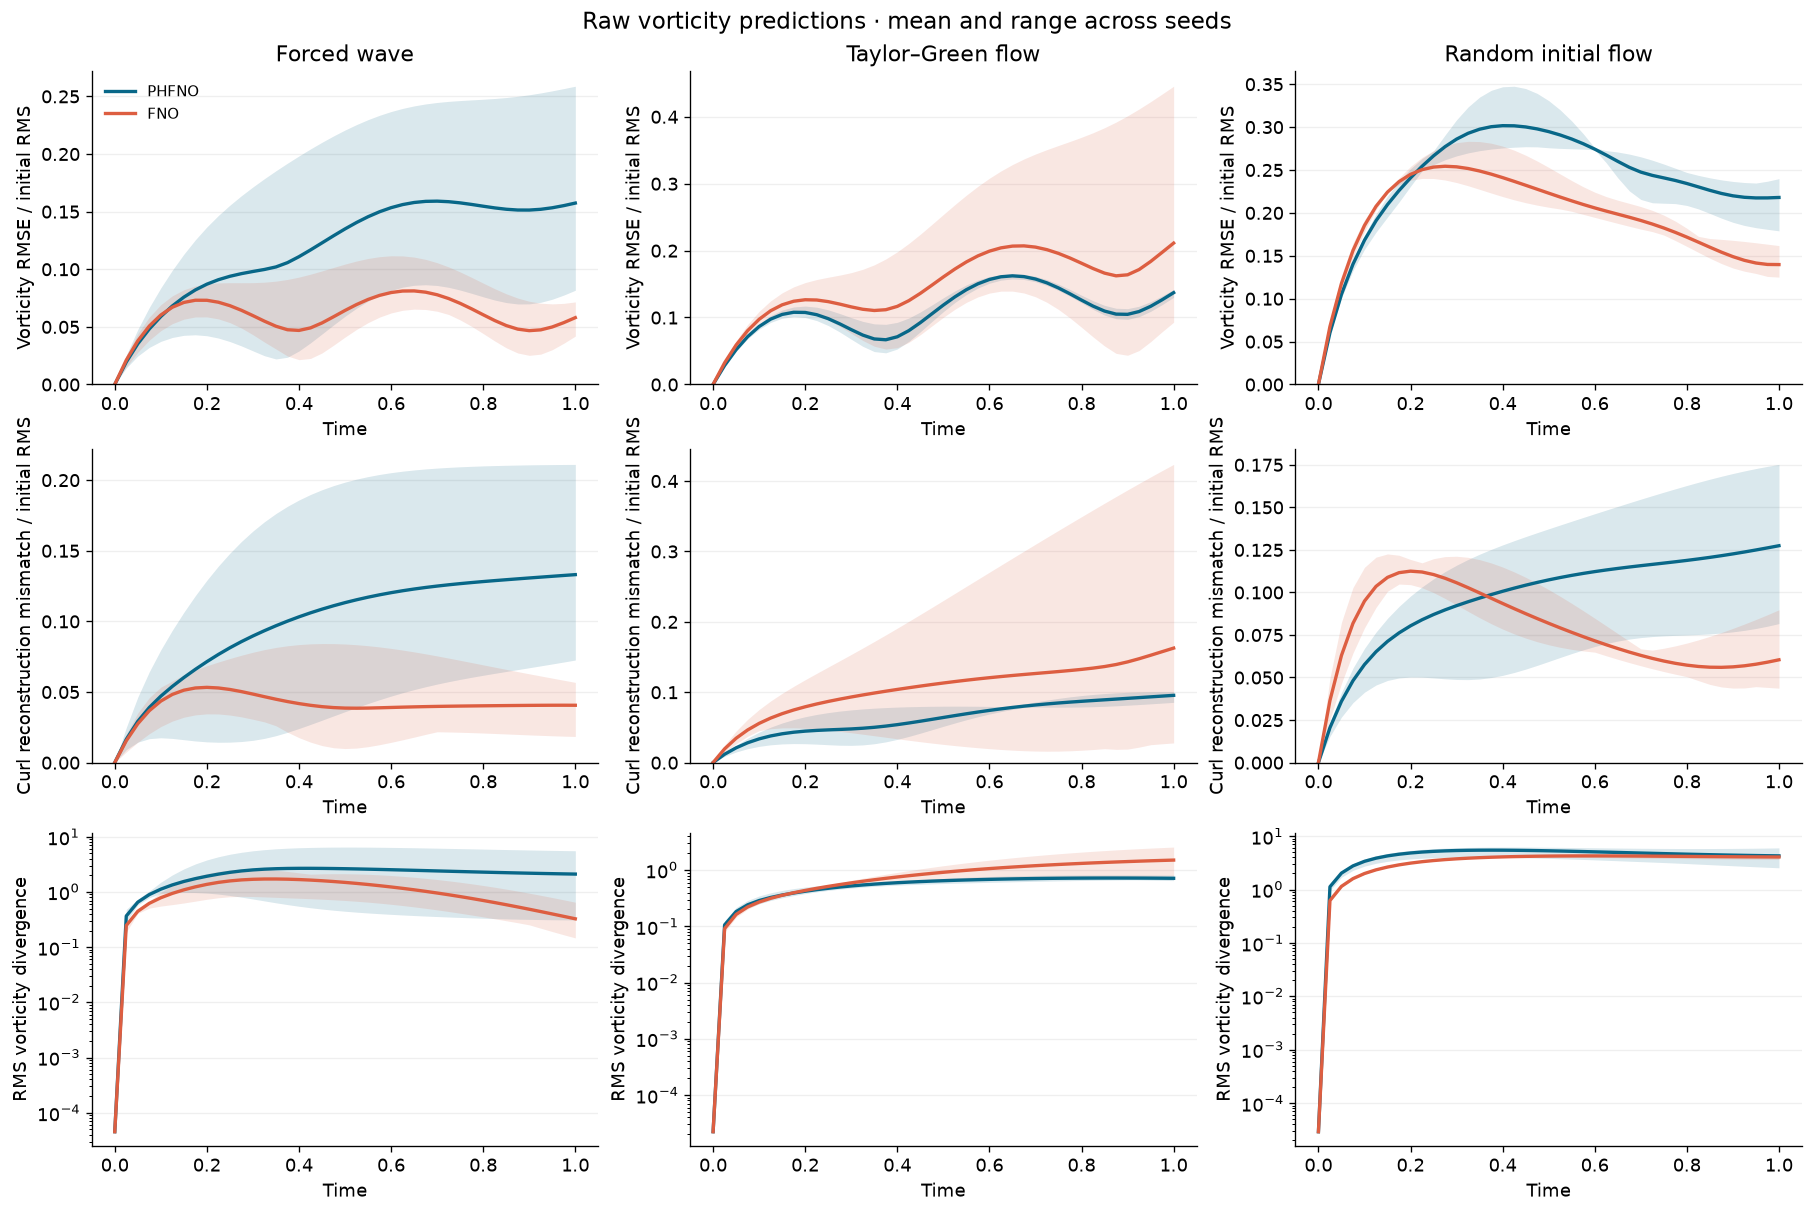

In [8]:
figure = vorticity_constraints(vorticity_results)
plt.show()

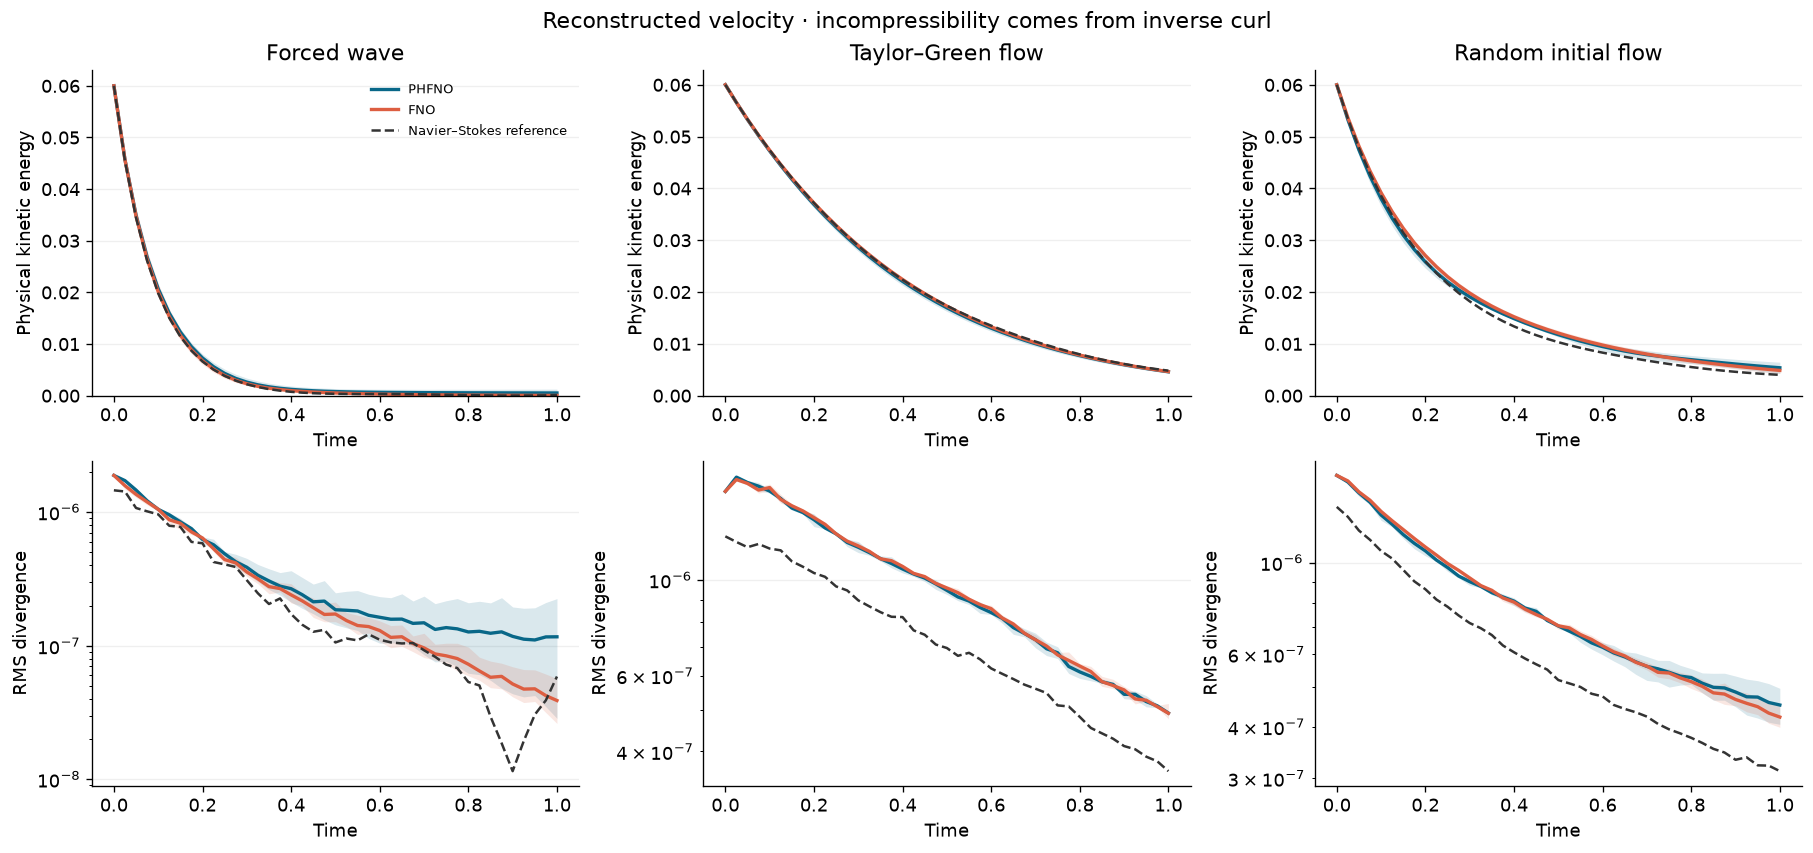

In [9]:
figure = physics_curves(vorticity_results)
figure.suptitle("Reconstructed velocity · incompressibility comes from inverse curl")
plt.show()

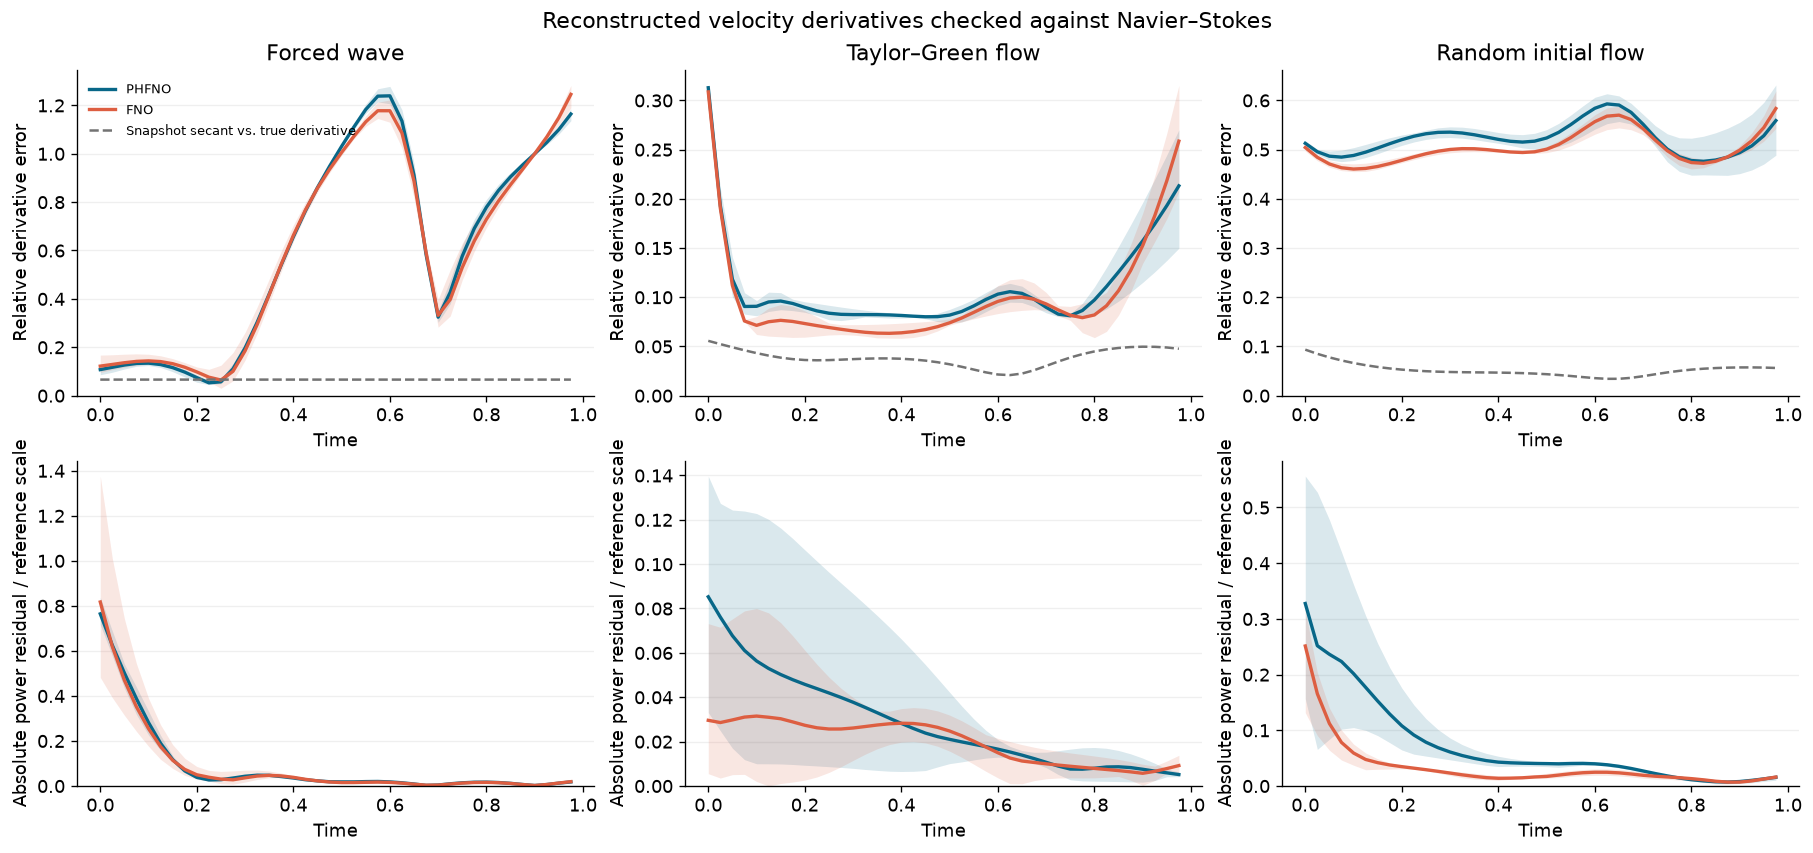

In [10]:
figure = equation_curves(vorticity_results)
figure.suptitle("Reconstructed velocity derivatives checked against Navier–Stokes")
plt.show()

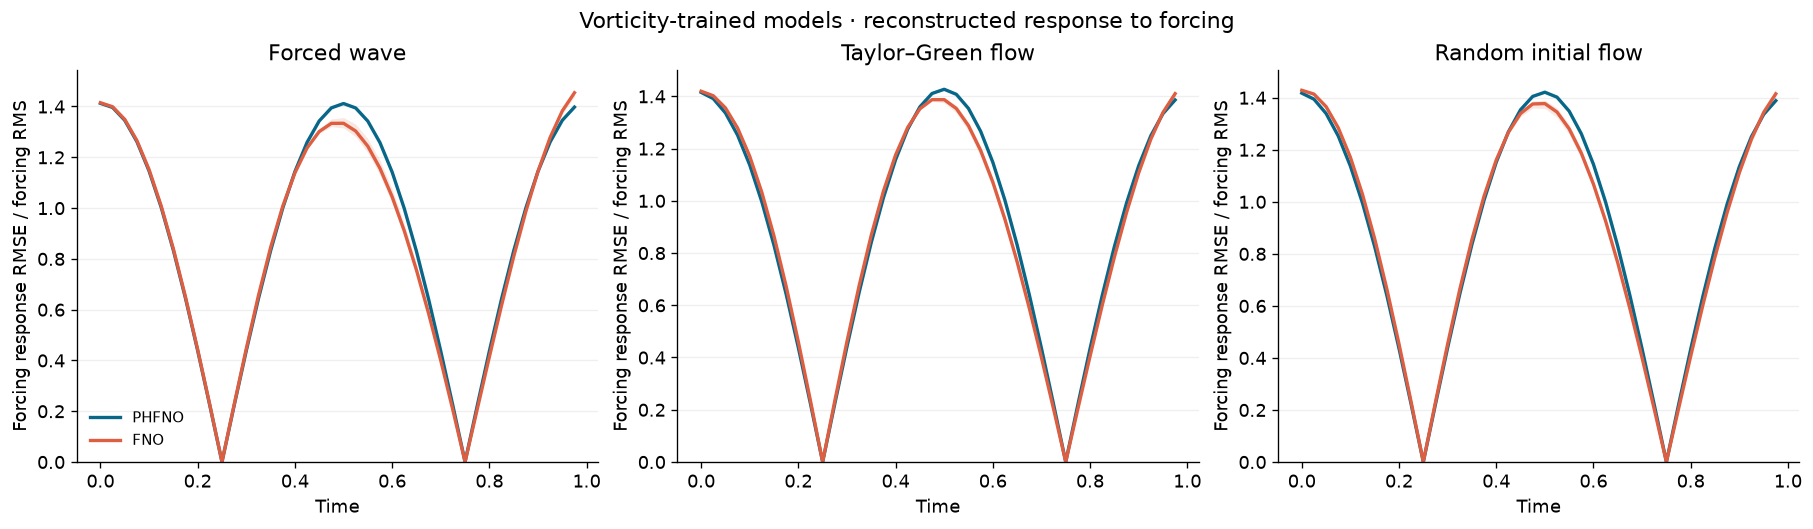

In [11]:
figure = forcing_curves(vorticity_results)
figure.suptitle("Vorticity-trained models · reconstructed response to forcing")
plt.show()

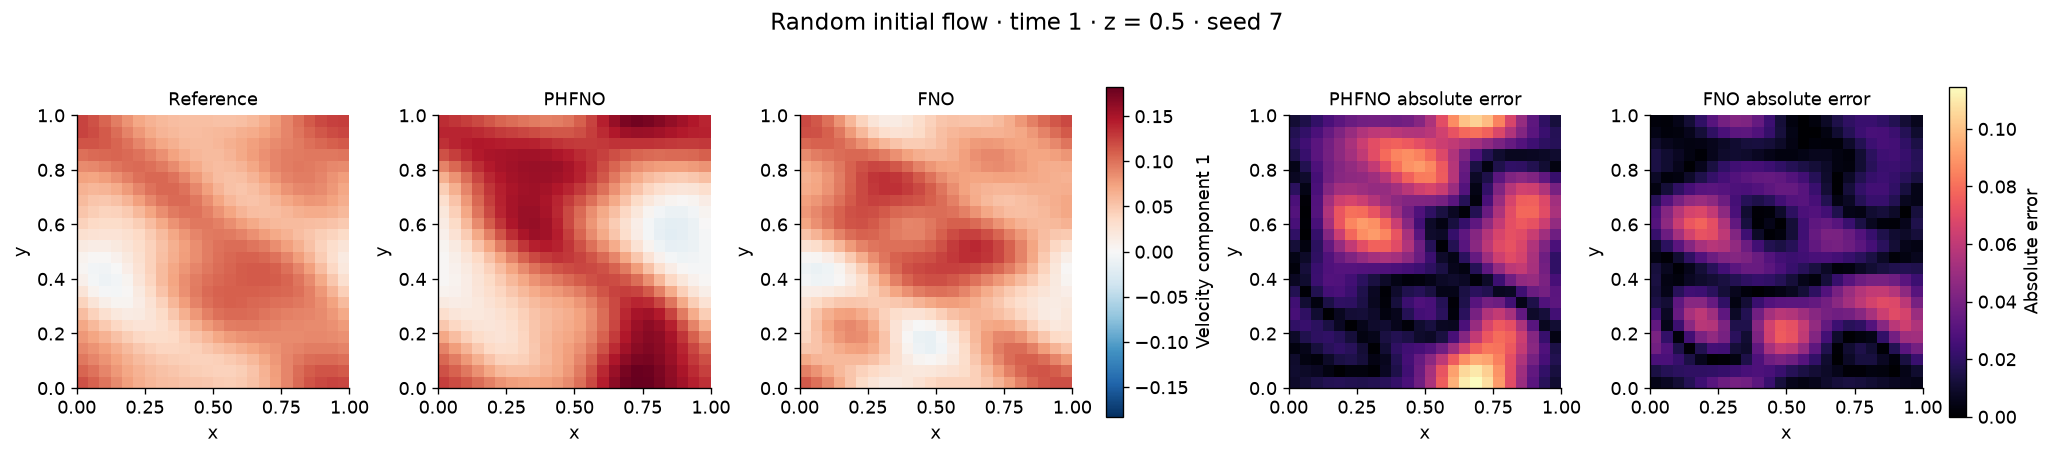

In [12]:
figure = field_slices(vorticity_results, family="random", seed=config.seeds[0])
plt.show()